#MASTER INTERNET DE LAS COSAS

#PROBLEMA DE DETECCIÓN Y CONTEO DE PERSONAS
Gissela Tasiguano

Contenido:

    1. ¿Qué es el conteo de objetos?
    2. Problema a resolver
    3. El set de datos a utilizar y librerías a usar
    4. Modelo Yolo
    5. Conteo de personas con Yolo

# 1. ¿Qué es el conteo de objetos?

Aplicación de visión por computador que consiste en detectar y realizar el conteo de diferentes tipo de objetos en una imagen.


# 2. Problema a resolver

Sistema de visión por computador capaz de realizar el conteo automático de personas.

# 3. SET DE DATOS A USAR Y LIBRERIAS REQUERIDAS

Se usó el dataset:

https://app.roboflow.com/gisselas-workspace-pku8a/personas_en_autobus_tesis/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

En este caso se utiliza:

801 imagenes de entrenamiento 70%

229 imágenes de prueba 20%

114 imágenes de validación 10%

Las imágenes de entrenamiento y validación se pueden usar para afinar un modelo YOLO de detección de objetos mientras que la prueba se usa para verificar el conteo de personas.



# MODELO YOLO
## 1. Montar Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Definir la ruta del ZIP y el destino

In [ ]:
ruta_zip = "/content/drive/MyDrive/TFM_Dataset/imagenes_yolov8_tesis.zip"
destino = "/content/dataset"

## 3. Crear la carpeta destino (si no existe)

In [ ]:
import os
os.makedirs(destino, exist_ok=True)

## 4. Descomprimir el ZIP

In [ ]:
!unzip -q "$ruta_zip" -d "$destino"

replace /content/dataset/train/images/test-video-8-00082_png_jpg.rf.c80e018f8b320a26b1c56d0c01538326.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## 5. Verificar que se descomprimió bien

In [ ]:
!ls "$destino"

dataset_imagenes_yolo  README.dataset.txt   test   valid
data.yaml	       README.roboflow.txt  train


## 6. Instalación de dependencias

Se instalaaron las librerías necesarias para el entrenamiento de YOLOv8, incluyendo el framework Ultralytics para detección de objetos.

In [ ]:
!pip install ultralytics

## 7. Importación de librerías

Se importo la librería Ultralytics para la construcción y el entrenamiento del modelo.



In [ ]:
from ultralytics import YOLO

# Análisis

## 1. Distribución de imagenes

Una vez descomprimida nuestra carpeta .zip podemos observar cuantas imaágenes contiene cada partición de cada Dataset (**train, valid, test**)

Se verifica que la división del dataset es correcta y no existe carpetas vacías.

Es un paso escencial antes del entrenamiento para asegurar la calidad del dataset.

In [ ]:
import os

train_images = len(os.listdir("/content/dataset/dataset_imagenes_yolo/train/images"))
valid_images = len(os.listdir("/content/dataset/dataset_imagenes_yolo/valid/images"))
test_images = len(os.listdir("/content/dataset/dataset_imagenes_yolo/test/images"))

print(train_images)
print(valid_images)
print(test_images)


801
229
114


## 2. Visualización de muestras

La selección de la imagen se hace de forma aleatoria del conjunto de entrenamiento y la muestra, permite comprobar de forma visual la calidad de la imagen, resolución, ilumicación y contenido.

Es útil para validar el dataset que se ha cargado correctamente y que las rutas estan bien definidas. En este caso la imagen no contiene las cajas por lo que la imagen se carga con PIL

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

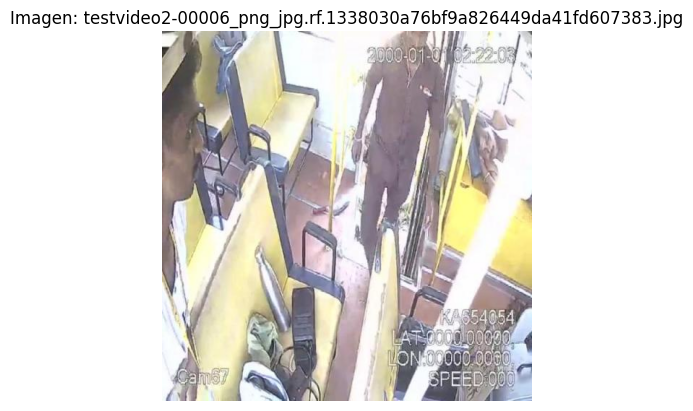

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Ruta real de tus imágenes
carpeta = "/content/dataset/dataset_imagenes_yolo/train/images"

# Listar todas las imágenes
imagenes = os.listdir(carpeta)

# Elegir una al azar
img_name = random.choice(imagenes)

# Cargar la imagen
img_path = os.path.join(carpeta, img_name)
img = Image.open(img_path)

# Mostrar
plt.imshow(img)
plt.title(f"Imagen: {img_name}")
plt.axis("off")



# Entrenamiento del modelo

## 1. Verificación del dataset

Se verificó la estructura generada por Roboflow y el archivo de configuración data.yaml, donde se especifica las rutas de entrenamiento, validación y prueba.

Se utiliza yolov8n.yaml que es solo la arquitectura sin pesos



In [ ]:
!ls /content/dataset/dataset_imagenes_yolo



data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


## 2. Carga del modelo

Para la carga del modelo se hace uso de **yolov8n.pt** para el Transfer Learning debido a la cantidad de datos, pesos entrenados como punto de partida, de esta forma se ahorra tiempo y recursos.

In [ ]:
model = YOLO("yolov8n.pt")  # modelo nano más pequeño

#Afina el modelo
model.train(
    data="/content/dataset/dataset_imagenes_yolo/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset_imagenes_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x784dd4e19c70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## 3. Validación

**Usa el data.yaml, evalua el rendimiento del modelo midiendo métricas como:**

1. Precisión (P o Box(P))con un valor de 0.895

Indica el porcentaje de las detecciones correctas con un valor alto con pocas alarmas falsas.

2. Recall (R) con un valor de 0.843

Indica el porcentaje de los objetos reales detectadas con un valor alto con pocos objetos perdidos.

3. mAP50 con un valor de 0.909

Mean Average Precision al IoU 0.50
Es la métrica más usada para comparar modelos de deteccion.

4. mAP50-95 con un valor de 0.657

Promedio de mAP desde IoU hasta 0.95
Es más exigente y refleja la cantidad fina de las cajas.

0.65 es un valor sólido para YOLOv8n siendo un modelo pequeño.

**Datos del dataset detectados por YOLO**

229 imágenes de validación

483 instancias (personas detectadas en total)

0 corruptas →  dataset limpio

**Velocidad del modelo**

2.9 ms preprocess

4.6 ms inference

2.5 ms postprocess

Esto significa que tu modelo corre en tiempo real en GPU.

In [ ]:
metrics = model.val()

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 780.8±298.8 MB/s, size: 42.0 KB)
val: Scanning /content/dataset/valid/labels.cache... 229 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 229/229 45.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.8it/s 4.0s
                   all        229        483      0.895      0.843      0.909      0.657
Speed: 2.9ms preprocess, 4.6ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val


## 3.1 Matriz de confusión

La matriz tiene dos clases persona y background(lo que no representa a persona)

Los valores observados son:

418 → persona predicha como persona (acierto, verdadero positivo)

115 → background predicho como persona (error, falso positivo)

45 → persona predicha como background (error, falso negativo)

El valor de background–background no se ve, pero es alto (color oscuro), lo cual es normal.

Esto significa:

El modelo detecta bien a las personas (418 aciertos).

A veces detecta personas donde no hay (115 falsos positivos).

A veces no detecta personas reales (45 falsos negativos).

Text(0.5, 1.0, 'Matriz de confusión')

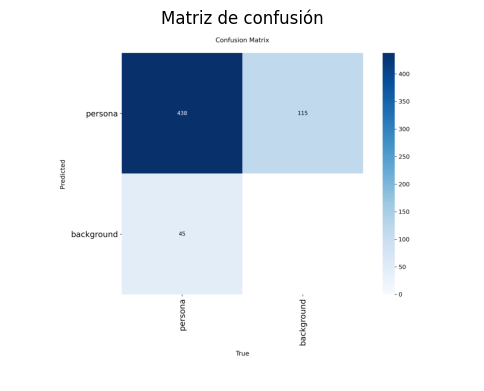

In [ ]:
img = Image.open("/content/runs/detect/val/confusion_matrix.png")
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Matriz de confusión")


## 4. Ubicación del modelo entrenado

El archivo best.pt es el modelo final entrenado y optimizado por YOLOv8 durante el proceso de transfer learning.
Representa la mejor versión del modelo obtenida durante todas las épocas de entrenamiento, seleccionada automáticamente según el rendimiento en el conjunto de validación y sirve para pruebas, inferencias y despliegue.

Incluye:

Los pesos ajustados del modelo base (yolov8n.pt) después del entrenamiento.

La arquitectura completa del modelo YOLOv8.

Las clases definidas en tu archivo data.yaml.

Las métricas que determinaron que este era el mejor checkpoint (por ejemplo, mayor mAP50-95).



In [ ]:
!ls runs/detect/train-3/weights

best.pt  last.pt


## 5. Prueba de inferencia

La prueba de inferencia se realiza utilizando una carpeta con imagenes nuevas y usando el archivo best.pt generada después del entrenamiento, se carga desde la ruta específica y se aplica la función model.predict() de Ultralytics YOLO que ayuda hacer inferencia y que ayude hacer la detección de imágenes.

Esto permite ejecutar la detección de objetos sobre una imagen de prueba, el sistema procesa la imagen y genera predicciones y guarda resultados incluyendo las cajas delimitadoras y probabilidades.


image 1/1 /content/drive/MyDrive/TFM_Dataset/bus_images/000032.jpg: 640x608 2 personas, 48.6ms
Speed: 3.4ms preprocess, 48.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 608)
Results saved to /content/runs/detect/predict-19
Imagen usada: 000032.jpg


(np.float64(-0.5), np.float64(1299.5), np.float64(1389.5), np.float64(-0.5))

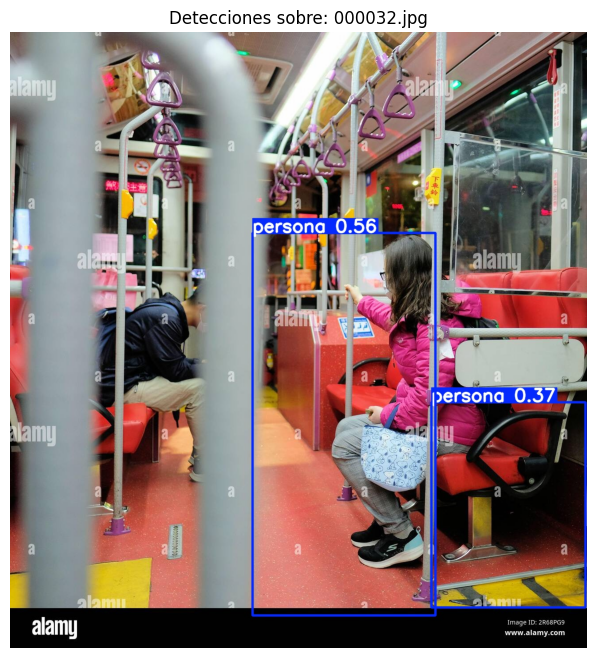

In [ ]:
from ultralytics import YOLO
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# 1. Cargar el modelo entrenado (best.pt)
model = YOLO("/content/runs/detect/train-3/weights/best.pt")

# 2. Carpeta donde tienes las imágenes nuevas
carpeta = "/content/drive/MyDrive/TFM_Dataset/bus_images"

# 3. Elegir imagen aleatoria
imagenes = os.listdir(carpeta)
img_name = random.choice(imagenes)
img_path = os.path.join(carpeta, img_name)

# 4. Inferencia
results = model.predict(
    source=img_path,
    save=True
)

print("Imagen usada:", img_name)

# 5. Mostrar la imagen con detecciones
ruta_salida = results[0].save_dir + "/" + img_name

img_detectada = Image.open(ruta_salida)

plt.figure(figsize=(8,8))
plt.imshow(img_detectada)
plt.title(f"Detecciones sobre: {img_name}")
plt.axis("off")


# Técnica de Explicabilidad XAI

## GRAD CAM

Grad‑CAM (Gradient‑weighted Class Activation Mapping) es una técnica de interpretabilidad que permite visualizar qué regiones de una imagen influyen más en la decisión de un modelo de visión por computadora.

En este proyecto, Grad‑CAM se implementó en Google Colab para analizar el comportamiento interno del modelo YOLOv8 entrenado.

La celda de código correspondiente realiza todo el proceso: carga el modelo best.pt, selecciona una imagen del conjunto de prueba, identifica la capa profunda del modelo donde se generan las activaciones más relevantes y calcula el mapa de calor mediante los gradientes asociados a la clase objetivo (persona).

Finalmente, el mapa Grad‑CAM se superpone sobre la imagen original, permitiendo interpretar visualmente qué zonas utiliza el modelo para detectar personas. Esta técnica aporta transparencia al modelo y respalda la validez de las predicciones.

## 1. Instalación de librerías

In [ ]:
!pip install ultralytics grad-cam opencv-python

## 2. Aplicación de GRAD CAM

La celda de código implementa el proceso completo para generar mapas de activación Grad‑CAM sobre el modelo YOLOv8 entrenado.

En primer lugar, se define una clase auxiliar que adapta la salida del modelo YOLOv8 al formato requerido por Grad‑CAM, permitiendo seleccionar la clase objetivo (en este caso, ‘persona’).

A continuación, se localiza una imagen del conjunto de prueba y se carga el modelo entrenado (best.pt).Después, se selecciona la última capa C2f del modelo como capa objetivo, ya que contiene las activaciones profundas más relevantes para la detección.

La imagen se preprocesa y se pasa al método Grad‑CAM, que calcula un mapa de calor indicando las regiones que el modelo considera más importantes para realizar la predicción.

Finalmente, el mapa de activación se superpone sobre la imagen original y se muestran ambas de forma comparativa, permitiendo interpretar visualmente qué zonas de la imagen influyen más en la decisión del modelo

Usando la imagen de tu dataset: dataset/dataset_imagenes_yolo/test/images/test-video3-00020_png_jpg.rf.e5f25870fcbcbf7157c565229ec99cd1.jpg


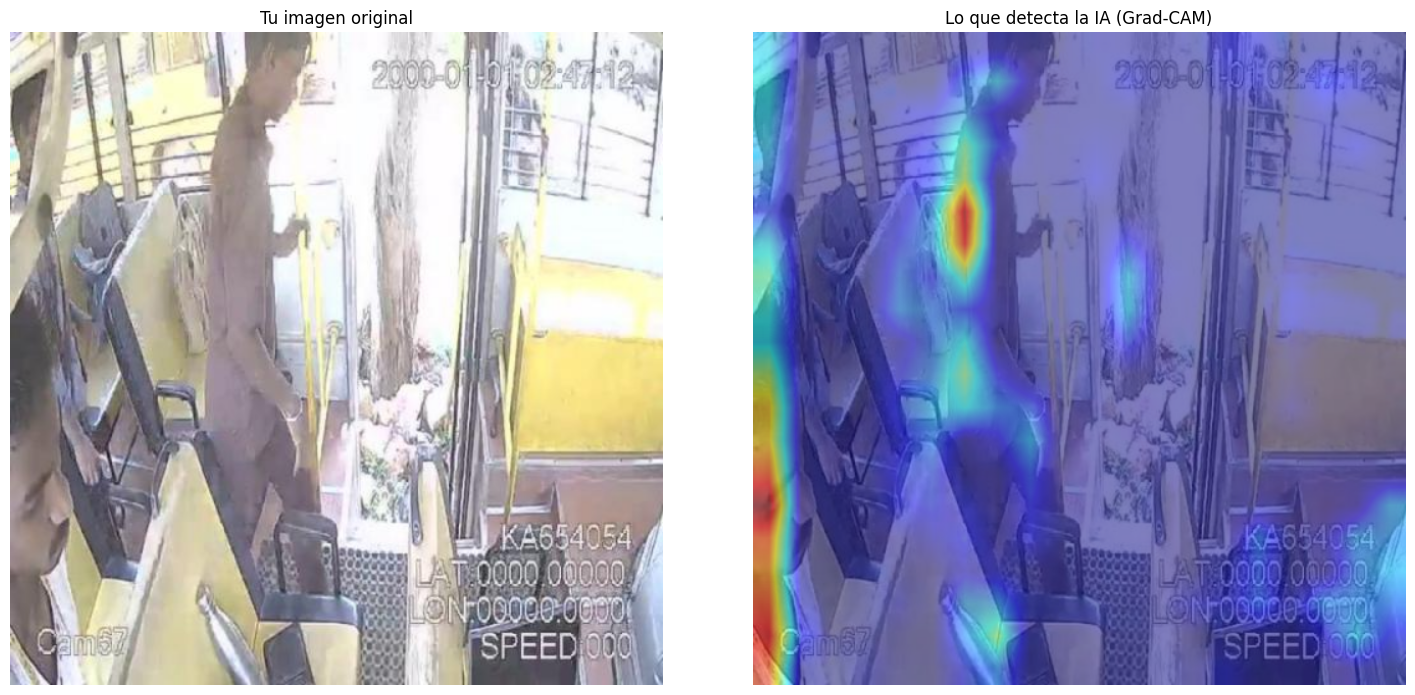

In [ ]:
import os
import glob
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


# 1. CLASE AUXILIAR ADAPTADA PARA YOLOv8

class YOLOv8Target:
    def __init__(self, category=0):
        self.category = category

    def __call__(self, model_output):
        if isinstance(model_output, (list, tuple)):
            pred = model_output[0]
        else:
            pred = model_output

        if len(pred.shape) == 3:
            pred = pred[0]

        return torch.sum(pred[self.category, :])


# 2. SELECCIONAR IMAGEN DE TU DATASET

# Buscamos en tu carpeta test/images (YOLO suele estructurarlo así internamente)
ruta_imagenes = "dataset/dataset_imagenes_yolo/test/images/*.jpg"
lista_imagenes = glob.glob(ruta_imagenes)

# Si la carpeta test está vacía o no tiene subcarpeta 'images', busca en todo 'test'
if len(lista_imagenes) == 0:
    ruta_imagenes = "dataset/dataset_imagenes_yolo/test/*.png"  # por si son .png
    lista_imagenes = glob.glob(ruta_imagenes) + glob.glob("dataset/dataset_imagenes_yolo/test/*.jpg")

# Si encuentra imágenes, toma la primera. Si no, pon la ruta manual:
if len(lista_imagenes) > 0:
    image_path = lista_imagenes[0]
    print(f"Usando la imagen de tu dataset: {image_path}")
else:
    # Si falla el buscador automático, pon aquí el nombre de una imagen tuva directamente:
    image_path = "dataset/dataset_imagenes_yolo/test/tu_imagen_ejemplo.jpg"
    print(f"No se autodetectaron imágenes, usando ruta manual: {image_path}")

# Leer tu imagen local
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen en la ruta: {image_path}. Verifica el nombre.")


# 3. CARGAR TU MODELO Y CONFIGURAR
model = YOLO("runs/detect/train-3/weights/best.pt")
net = model.model

net.eval()
for param in net.parameters():
    param.requires_grad = True

# Seleccionar la capa objetivo (última C2f)
target_layers = [net.model[-2]]

# Preparar imagen
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))

input_tensor = torch.from_numpy(img_resized).float().permute(2, 0, 1).unsqueeze(0) / 255.0
input_tensor.requires_grad = True

# Configurar Grad-CAM
cam = GradCAM(model=net, target_layers=target_layers)
targets = [YOLOv8Target(category=0)]

# 4. GENERAR GRAD-CAM
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
img_float = np.float32(img_resized) / 255.0
cam_image = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)


# 5. MOSTRAR RESULTADO EN LA CELDA (ORIGINAL VS GRAD-CAM)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Imagen original de tu dataset
axes[0].imshow(img_resized)
axes[0].set_title("Tu imagen original")
axes[0].axis('off')

# Mapa de calor de tu modelo
axes[1].imshow(cam_image)
axes[1].set_title("Lo que detecta la IA (Grad-CAM)")
axes[1].axis('off')

plt.tight_layout()
plt.show()